# 07d — Deep Hedging

**summary**: trains a log-signature policy network to hedge a 30-day Asian put option on GB electricity prices by minimising CVaR of residual P&L, comparing against an analytic Schwartz OU delta method.

In [1]:
# Cell 1 — Mount and install
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

%pip install -q iisignature
print("iisignature installed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
iisignature installed.


In [11]:
# Cell 2 — Imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import iisignature
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
from numpy.linalg import matrix_power
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [12]:
# Cell 3 — Schwartz OU price path simulation
import json
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR   = Path("/content/drive/MyDrive/energy_synthetic_data/data")
N_PATHS    = 10_000
T_DAYS     = 30
K_STRIKE   = 80.0
SEED       = 42
rng        = np.random.default_rng(SEED)

with open(DATA_DIR / "gas_storage_summary.json") as f:
    sp = json.load(f)["schwartz_params"]

KAPPA = sp["kappa"]   # mean-reversion speed
MU    = sp["mu"]      # long-run mean £/MWh
SIGMA = sp["sigma"]   # volatility £/MWh

# Initial price: draw from stationary OU distribution N(mu, sigma²/2kappa)
sigma_stat = SIGMA / np.sqrt(2 * KAPPA)
S0 = rng.normal(MU, sigma_stat, size=N_PATHS)
S0 = np.clip(S0, 1.0, None)   # no negative starting prices

# Simulate T_DAYS daily OU steps
# S_{t+1} = e^{-kappa} S_t + (1-e^{-kappa}) mu + sigma_step * Z
e_k        = np.exp(-KAPPA)
sigma_step = SIGMA * np.sqrt((1 - np.exp(-2 * KAPPA)) / (2 * KAPPA))

paths = np.zeros((N_PATHS, T_DAYS))
paths[:, 0] = S0
for t in range(1, T_DAYS):
    Z = rng.standard_normal(N_PATHS)
    paths[:, t] = e_k * paths[:, t-1] + (1 - e_k) * MU + sigma_step * Z

# Normalise by strike
paths_norm = paths / K_STRIKE

print(f"Schwartz OU paths: {N_PATHS:,} × {T_DAYS} days")
print(f"Parameters: κ={KAPPA:.4f}, μ=£{MU:.2f}, σ=£{SIGMA:.2f}")
print(f"Raw prices  — mean: £{paths.mean():.2f}, std: £{paths.std():.2f}")
print(f"Norm prices — mean: {paths_norm.mean():.4f}, std: {paths_norm.std():.4f}")

# Rename to match downstream cells
bootstrap_paths_norm = paths_norm

Schwartz OU paths: 10,000 × 30 days
Parameters: κ=0.1688, μ=£82.08, σ=£37.65
Raw prices  — mean: £82.72, std: £64.05
Norm prices — mean: 1.0339, std: 0.8006


In [13]:
# Cell 4 — Option parameters, payoffs, train/test split (normalised units)

K_NORM   = 1.0           # strike in normalised units (= K_STRIKE / K_STRIKE)
ALPHA    = 0.95
COST_BPS = (0.5 / K_STRIKE)   # transaction cost normalised (~0.00625 per unit delta)

# All paths and payoffs in normalised units from here on
avg_prices = bootstrap_paths_norm.mean(axis=1)
Z_all      = np.maximum(K_NORM - avg_prices, 0.0)

print(f"Strike (normalised): {K_NORM:.3f}")
print(f"Mean 30-day avg price (norm): {avg_prices.mean():.4f}  "
      f"(= £{avg_prices.mean()*K_STRIKE:.2f}/MWh)")
print(f"Option ITM rate: {(Z_all > 0).mean()*100:.1f}%")
print(f"Mean payoff (ITM paths): {Z_all[Z_all>0].mean():.4f}  "
      f"(= £{Z_all[Z_all>0].mean()*K_STRIKE:.2f}/MWh)")
print(f"Mean payoff (all paths): {Z_all.mean():.4f}  "
      f"(= £{Z_all.mean()*K_STRIKE:.2f}/MWh)")

from sklearn.model_selection import train_test_split
path_idx = np.arange(N_PATHS)
train_idx, test_idx = train_test_split(path_idx, test_size=0.2, random_state=SEED)
print(f"\nTrain paths: {len(train_idx):,} | Test paths: {len(test_idx):,}")

# All downstream cells use normalised paths
train_paths   = bootstrap_paths_norm[train_idx]
test_paths    = bootstrap_paths_norm[test_idx]
Z_train       = Z_all[train_idx]
Z_test        = Z_all[test_idx]
regimes_train = bootstrap_regimes[train_idx]
regimes_test  = bootstrap_regimes[test_idx]

Strike (normalised): 1.000
Mean 30-day avg price (norm): 1.0339  (= £82.72/MWh)
Option ITM rate: 47.5%
Mean payoff (ITM paths): 0.3402  (= £27.22/MWh)
Mean payoff (all paths): 0.1616  (= £12.93/MWh)

Train paths: 8,000 | Test paths: 2,000


In [14]:
# Cell 5 — Running log-signatures
#
# At step t, the policy network receives the log-signature of the price path
# (time, price) up to and including t. This makes the network causal.
#
# Path: 2D (time normalised to [0,1], normalised price)
# Depth: 3  →  logsig_dim = 5 (2 + 1 + 2 Lie algebra generators)
# Network input: logsig (5) + t/T (1) = 6 dimensions
#
# This cell is CPU-bound (iisignature does not use GPU).
# Output is saved to disk so training cell can be re-run without recomputing.

SIG_DEPTH  = 3
PREP       = iisignature.prepare(2, SIG_DEPTH)
LOGSIG_DIM = iisignature.logsiglength(2, SIG_DEPTH)   # 5
print(f"Log-signature dimension (2D, depth {SIG_DEPTH}): {LOGSIG_DIM}")
print(f"Policy network input dimension: {LOGSIG_DIM + 1} (logsig + t/T)")

SAVE_PATH_TRAIN = DATA_DIR / "07d_running_logsigs_train.npy"
SAVE_PATH_TEST  = DATA_DIR / "07d_running_logsigs_test.npy"

def compute_running_logsigs(price_paths, depth, prep, desc=""):
    """
    price_paths: (N, T) daily prices
    Returns:     (N, T, logsig_dim)  — causal running log-signatures

    At step t, builds a 2D path [(0, S_0), (1/T, S_1), ..., (t/T, S_t)]
    normalised so price has zero mean and unit std over [0, t].
    If std < 1e-8 (flat path), centres only.
    """
    N, T = price_paths.shape
    logsig_dim = iisignature.logsiglength(2, depth)
    result = np.zeros((N, T, logsig_dim), dtype=np.float32)

    for i in tqdm(range(N), desc=desc, miniters=500):
        for t in range(T):
            sub_prices = price_paths[i, :t + 1]        # length t+1
            p_mean = sub_prices.mean()
            p_std  = sub_prices.std()
            if p_std < 1e-8:
                p_norm = sub_prices - p_mean
            else:
                p_norm = (sub_prices - p_mean) / p_std
            t_coords = np.linspace(0.0, 1.0, t + 1)
            path     = np.column_stack([t_coords, p_norm])   # (t+1, 2)
            if len(path) < 2:
                # Single point — log-signature is zero by convention
                result[i, t] = 0.0
            else:
                result[i, t] = iisignature.logsig(path, prep)
    return result

# Load from disk if already computed, otherwise compute and save
if SAVE_PATH_TRAIN.exists() and SAVE_PATH_TEST.exists():
    print("Loading pre-computed running log-signatures from disk...")
    running_logsigs_train = np.load(SAVE_PATH_TRAIN)   # (8000, 30, 5)
    running_logsigs_test  = np.load(SAVE_PATH_TEST)    # (2000, 30, 5)
    print(f"Train: {running_logsigs_train.shape}")
    print(f"Test:  {running_logsigs_test.shape}")
else:
    print("Computing running log-signatures — CPU-bound, takes ~3-5 min...")
    running_logsigs_train = compute_running_logsigs(
        train_paths, SIG_DEPTH, PREP, desc="Train paths")
    running_logsigs_test  = compute_running_logsigs(
        test_paths,  SIG_DEPTH, PREP, desc="Test paths")
    np.save(SAVE_PATH_TRAIN, running_logsigs_train)
    np.save(SAVE_PATH_TEST,  running_logsigs_test)
    print(f"Saved running log-signatures to {DATA_DIR}")
    print(f"Train: {running_logsigs_train.shape}")
    print(f"Test:  {running_logsigs_test.shape}")

Log-signature dimension (2D, depth 3): 5
Policy network input dimension: 6 (logsig + t/T)
Loading pre-computed running log-signatures from disk...
Train: (8000, 30, 5)
Test:  (2000, 30, 5)


In [15]:
# Cell 6 — Schwartz OU analytic baseline (normalised units)

import json
from scipy.stats import norm as scipy_norm

with open(DATA_DIR / "gas_storage_summary.json") as f:
    schwartz_params = json.load(f)

# Raw OU parameters
KAPPA = schwartz_params["schwartz_params"]["kappa"]
MU    = schwartz_params["schwartz_params"]["mu"]
SIGMA = schwartz_params["schwartz_params"]["sigma"]

# Normalised OU parameters (divide price-denominated params by K_STRIKE)
# KAPPA is a rate (1/day) — unchanged
MU_NORM    = MU    / K_STRIKE
SIGMA_NORM = SIGMA / K_STRIKE

print("Schwartz OU parameters:")
print(f"  κ:      {KAPPA:.4f} /day  (half-life {np.log(2)/KAPPA:.1f} days)")
print(f"  μ:      £{MU:.2f}/MWh  →  {MU_NORM:.4f} normalised")
print(f"  σ:      £{SIGMA:.2f}/MWh  →  {SIGMA_NORM:.4f} normalised")

def compute_G(t, T, kappa):
    n = T - 1 - t
    if n <= 0:
        return 0.0
    if abs(kappa) < 1e-10:
        return float(n)
    return np.exp(-kappa) * (1 - np.exp(-kappa * n)) / (1 - np.exp(-kappa))

def compute_var_R(t, T, kappa, sigma_norm):
    """Var[R_t | S_t] in normalised units."""
    n = T - 1 - t
    if n <= 0:
        return 0.0
    i = np.arange(1, n + 1, dtype=float)
    I, J = np.meshgrid(i, i)
    cov_mat = (sigma_norm**2 / (2 * kappa)) * (
        np.exp(-kappa * np.abs(I - J)) - np.exp(-kappa * (I + J))
    )
    return float(cov_mat.sum())

G_t    = np.array([compute_G(t, T_DAYS, KAPPA)             for t in range(T_DAYS)])
VarR_t = np.array([compute_var_R(t, T_DAYS, KAPPA, SIGMA_NORM) for t in range(T_DAYS)])

print(f"\nG(t=0)={G_t[0]:.3f}, G(t=29)={G_t[29]:.3f}")
print(f"Var[R_t] at t=0: {VarR_t[0]:.4f}, at t=28: {VarR_t[28]:.6f}  (normalised units)")

def schwartz_delta_paths(price_paths, T, K_norm, mu_norm, G_t, VarR_t):
    """
    Analytic Schwartz delta for all paths and steps, in normalised units.
    price_paths: (N, T) — normalised prices
    Returns:     (N, T) — hedge ratios in [0, 1]
    """
    N      = price_paths.shape[0]
    deltas = np.zeros((N, T), dtype=float)
    cumsum = np.cumsum(price_paths, axis=1)

    for t in range(T):
        n = T - 1 - t
        if n <= 0:
            deltas[:, t] = 0.0
            continue
        S_t   = price_paths[:, t]
        cs    = cumsum[:, t]
        K_eff = K_norm * T - cs          # adjusted strike for remaining sum (normalised)
        m_R   = n * mu_norm + (S_t - mu_norm) * G_t[t]
        v     = VarR_t[t]
        if v <= 0:
            deltas[:, t] = 0.0
            continue
        d             = (m_R - K_eff) / np.sqrt(v)
        prob_itm      = scipy_norm.cdf(-d)
        deltas[:, t]  = (1.0 / T) * G_t[t] * prob_itm

    return np.clip(deltas, 0.0, 1.0)

delta_schwartz_train = schwartz_delta_paths(
    train_paths, T_DAYS, K_NORM, MU_NORM, G_t, VarR_t)
delta_schwartz_test  = schwartz_delta_paths(
    test_paths,  T_DAYS, K_NORM, MU_NORM, G_t, VarR_t)

print(f"\nSchwartz delta — mean: {delta_schwartz_train.mean():.4f}, "
      f"max: {delta_schwartz_train.max():.4f}")
print(f"Expected payoff E[Z]:  {Z_train.mean():.4f}")
print(f"Ratio delta/payoff sanity check: "
      f"{delta_schwartz_train.mean() / Z_train.mean():.1f}x")

Schwartz OU parameters:
  κ:      0.1688 /day  (half-life 4.1 days)
  μ:      £82.08/MWh  →  1.0259 normalised
  σ:      £37.65/MWh  →  0.4706 normalised

G(t=0)=5.398, G(t=29)=0.000
Var[R_t] at t=0: 161.2643, at t=28: 0.187972  (normalised units)

Schwartz delta — mean: 0.0674, max: 0.1758
Expected payoff E[Z]:  0.1622
Ratio delta/payoff sanity check: 0.4x


In [16]:
# Cell 7 — Policy network
#
# Input:  log-signature of path up to t (5 dims) + t/T (1 dim) = 6 dims
# Hidden: 2 layers of 64 units, ReLU
# Output: 1 scalar in (0, 1) — hedge ratio δ_t
#
# Small by design: 10,000 paths × 30 steps, overfitting risk is real.
# The log-signature provides a fixed-dimension summary of path history;
# no recurrence needed.

class HedgeNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, n_layers=2):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """x: (batch, input_dim) → (batch, 1)"""
        return self.net(x)


INPUT_DIM  = LOGSIG_DIM + 1   # 5 + 1 = 6
HIDDEN_DIM = 64
N_LAYERS   = 2

model = HedgeNet(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"HedgeNet: input={INPUT_DIM}, hidden={HIDDEN_DIM}×{N_LAYERS}, output=1")
print(f"Trainable parameters: {n_params:,}")
print(model)

HedgeNet: input=6, hidden=64×2, output=1
Trainable parameters: 4,673
HedgeNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [17]:
# Cell 8 — CVaR loss (Rockafellar-Uryasev)
#
# P&L of hedged short-put position for scenario i:
#   pnl_i = -Z_i + Σ_t δ_t^i * (S_{t+1}^i - S_t^i) - Σ_t cost * |δ_{t+1} - δ_t|
#
# Positive pnl = profitable hedge, negative = loss.
#
# CVaR at level α (Rockafellar-Uryasev 2000):
#   CVaR_α(L) = min_z  { z + 1/(1-α) * E[max(-pnl - z, 0)] }
#
# We minimise over network parameters θ AND the scalar threshold z jointly.
# z is a learnable nn.Parameter — not fixed.
# The gradient flows through z into the hinge term automatically.

def compute_pnl(deltas, price_paths, Z, cost_bps):
    """
    deltas:      (N, T)   — hedge ratios from network or baseline
    price_paths: (N, T)   — daily prices S_0,...,S_{T-1}
    Z:           (N,)     — terminal payoff (liability)
    cost_bps:    float    — transaction cost per unit of delta change

    Returns: pnl (N,) — P&L of hedged position (positive = gain)
    """
    # Daily price changes S_{t+1} - S_t
    # At t=T-1 there is no S_T; no hedge P&L at last step
    price_changes = price_paths[:, 1:] - price_paths[:, :-1]  # (N, T-1)
    hedge_pnl     = - (deltas[:, :-1] * price_changes).sum(axis=1)  # (N,)

    # Transaction costs: proportional to change in delta
    # At t=0, cost is on initial delta (from zero)
    delta_changes = torch.cat([
        deltas[:, :1],                            # initial position from 0
        torch.abs(deltas[:, 1:] - deltas[:, :-1]) # subsequent rebalancing
    ], dim=1)                                     # (N, T)
    tc = cost_bps * delta_changes.sum(dim=1)      # (N,)

    pnl = -Z + hedge_pnl - tc
    return pnl


def cvar_loss(pnl, z, alpha=0.95):
    """
    Rockafellar-Uryasev CVaR loss.
    pnl: (N,) tensor — positive = profit
    z:   scalar tensor (learnable) — the VaR threshold
    Returns: scalar CVaR estimate (to be minimised)
    """
    losses = -pnl                                          # (N,) losses
    cvar   = z + (1.0 / (1.0 - alpha)) * F.relu(losses - z).mean()
    return cvar


print("CVaR loss and P&L functions defined.")
print(f"Alpha: {ALPHA}  |  Transaction cost: £{COST_BPS}/MWh per unit δ change")

CVaR loss and P&L functions defined.
Alpha: 0.95  |  Transaction cost: £0.00625/MWh per unit δ change


In [18]:
# Cell 9 — Training loop
#
# Batch over paths (not steps — the full 30-step trajectory is forward-passed
# at once by indexing the pre-computed running log-signatures).
# z (VaR threshold) is optimised jointly with θ via AdamW.

LR         = 1e-3
N_EPOCHS   = 200
BATCH_SIZE = 512

# Convert training data to tensors
# running_logsigs_train: (8000, 30, 5)  →  need to append t/T
t_frac = torch.tensor(
    np.tile(np.arange(T_DAYS, dtype=np.float32) / T_DAYS, (len(train_idx), 1)),
    device=DEVICE
)   # (8000, 30)

logsigs_tr  = torch.tensor(running_logsigs_train, device=DEVICE)  # (8000, 30, 5)
prices_tr   = torch.tensor(train_paths.astype(np.float32), device=DEVICE)
Z_tr        = torch.tensor(Z_train.astype(np.float32), device=DEVICE)

# Learnable VaR threshold — initialise at the empirical 95th percentile loss
z_init = float(np.percentile(-Z_train, ALPHA * 100))  # rough initialisation
z_param = nn.Parameter(torch.tensor(z_init, device=DEVICE))

optimiser = torch.optim.AdamW(
    list(model.parameters()) + [z_param],
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=N_EPOCHS, eta_min=LR/50)

N_TRAIN   = len(train_idx)
cvar_history = []

model.train()
for epoch in tqdm(range(N_EPOCHS), desc="Training HedgeNet"):
    perm = torch.randperm(N_TRAIN, device=DEVICE)
    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx_b = perm[start:start + BATCH_SIZE]   # (B,)
        B     = len(idx_b)

        # Build network inputs: (B, T, LOGSIG_DIM+1)
        ls_b  = logsigs_tr[idx_b]              # (B, T, 5)
        tf_b  = t_frac[idx_b].unsqueeze(-1)    # (B, T, 1)
        x_b   = torch.cat([ls_b, tf_b], dim=-1)  # (B, T, 6)

        # Forward pass: apply network at every step jointly
        # Reshape to (B*T, 6), forward, reshape back to (B, T)
        x_flat    = x_b.reshape(B * T_DAYS, INPUT_DIM)
        delta_flat = model(x_flat)             # (B*T, 1)
        deltas_b   = delta_flat.reshape(B, T_DAYS)  # (B, T)

        p_b = prices_tr[idx_b]
        z_b = Z_tr[idx_b]

        pnl  = compute_pnl(deltas_b, p_b, z_b, COST_BPS)
        loss = cvar_loss(pnl, z_param, alpha=ALPHA)

        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(list(model.parameters()) + [z_param], max_norm=1.0)
        optimiser.step()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = epoch_loss / n_batches
    cvar_history.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | CVaR loss: {avg_loss:.4f} | z: {z_param.item():.4f} | "
              f"lr: {scheduler.get_last_lr()[0]:.2e}")

# Save model
torch.save(model.state_dict(), DATA_DIR / "deep_hedge_model.pt")
print(f"\nModel saved to deep_hedge_model.pt")
print(f"Final CVaR loss: {cvar_history[-1]:.4f}")
print(f"Learnt z (VaR threshold): {z_param.item():.4f}")

Epoch  20 | CVaR loss: 1.2990 | z: 0.3200 | lr: 9.76e-04
Epoch  40 | CVaR loss: 0.8332 | z: 0.5863 | lr: 9.06e-04
Epoch  60 | CVaR loss: 0.8085 | z: 0.6481 | lr: 7.98e-04
Epoch  80 | CVaR loss: 0.8064 | z: 0.6591 | lr: 6.61e-04
Epoch 100 | CVaR loss: 0.8037 | z: 0.6597 | lr: 5.10e-04
Epoch 120 | CVaR loss: 0.8006 | z: 0.6596 | lr: 3.59e-04
Epoch 140 | CVaR loss: 0.8010 | z: 0.6589 | lr: 2.22e-04
Epoch 160 | CVaR loss: 0.8011 | z: 0.6586 | lr: 1.14e-04
Epoch 180 | CVaR loss: 0.7978 | z: 0.6585 | lr: 4.40e-05
Epoch 200 | CVaR loss: 0.8000 | z: 0.6584 | lr: 2.00e-05

Model saved to deep_hedge_model.pt
Final CVaR loss: 0.8000
Learnt z (VaR threshold): 0.6584


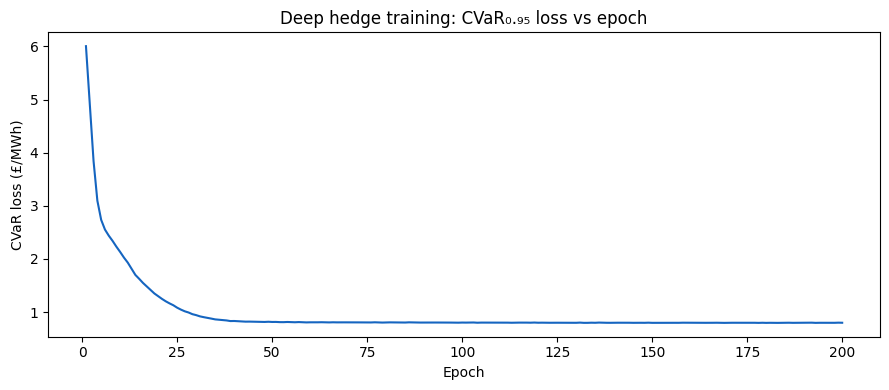

Saved: 07d_training_curve.png


In [19]:
# Cell 10 — Training curve

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_EPOCHS + 1), cvar_history, lw=1.5, color="#1565C0")
ax.set_xlabel("Epoch")
ax.set_ylabel("CVaR loss (£/MWh)")
ax.set_title("Deep hedge training: CVaR₀.₉₅ loss vs epoch")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
plt.tight_layout()
plt.savefig(DATA_DIR / "07d_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07d_training_curve.png")

In [20]:
# Cell 11 — Evaluate on held-out test paths
#
# Produce P&L for the deep hedge on 2,000 test paths.
# No gradient computation.

model.eval()

# Test tensors
t_frac_test = torch.tensor(
    np.tile(np.arange(T_DAYS, dtype=np.float32) / T_DAYS, (len(test_idx), 1)),
    device=DEVICE
)   # (2000, 30)
logsigs_te  = torch.tensor(running_logsigs_test, device=DEVICE)
prices_te   = torch.tensor(test_paths.astype(np.float32), device=DEVICE)
Z_te        = torch.tensor(Z_test.astype(np.float32), device=DEVICE)

with torch.no_grad():
    ls_te   = logsigs_te                          # (2000, 30, 5)
    tf_te   = t_frac_test.unsqueeze(-1)           # (2000, 30, 1)
    x_te    = torch.cat([ls_te, tf_te], dim=-1)   # (2000, 30, 6)
    N_te    = len(test_idx)
    x_flat  = x_te.reshape(N_te * T_DAYS, INPUT_DIM)
    d_flat  = model(x_flat)
    deltas_deep_test = d_flat.reshape(N_te, T_DAYS)   # (2000, 30)

    pnl_deep = compute_pnl(deltas_deep_test, prices_te, Z_te, COST_BPS).cpu().numpy()

# CVaR of deep hedge on test set
def empirical_cvar(pnl, alpha=0.95):
    losses = -pnl
    var    = np.quantile(losses, alpha)
    cvar   = losses[losses >= var].mean()
    return float(var), float(cvar)

var_deep, cvar_deep = empirical_cvar(pnl_deep)
print("Deep hedge — test set:")
print(f"  Mean P&L:  £{pnl_deep.mean():.4f}/MWh")
print(f"  Std P&L:   £{pnl_deep.std():.4f}/MWh")
print(f"  VaR₀.₉₅:   £{var_deep:.4f}/MWh")
print(f"  CVaR₀.₉₅:  £{cvar_deep:.4f}/MWh")

Deep hedge — test set:
  Mean P&L:  £-0.1647/MWh
  Std P&L:   £0.3010/MWh
  VaR₀.₉₅:   £0.6710/MWh
  CVaR₀.₉₅:  £0.8036/MWh


In [26]:
# Diagnostic: mean delta over all test paths and steps - - I think it needs checking that it learns to hedge not speculate
print(f"Deep hedge mean delta:    {delta_deep_np.mean():.4f}")
print(f"Schwartz mean delta:      {delta_sw_te.mean():.4f}")
print(f"Deep hedge P&L decomposition:")
price_changes_te = test_paths[:, 1:] - test_paths[:, :-1]
hedge_pnl_deep = -(delta_deep_np[:, :-1] * price_changes_te).sum(axis=1)
print(f"  Mean hedge P&L:  £{hedge_pnl_deep.mean():.2f}")
print(f"  Mean -Z:         £{(-Z_test).mean():.2f}")
print(f"  Mean total P&L:  £{pnl_deep.mean():.2f}")

Deep hedge mean delta:    0.1385
Schwartz mean delta:      0.0679
Deep hedge P&L decomposition:
  Mean hedge P&L:  £-0.00
  Mean -Z:         £-0.16
  Mean total P&L:  £-0.16


In [22]:
# Cell 12 — Baseline comparisons
#
# Three baselines vs deep hedge, all evaluated on test set:
#
# 1. Zero hedge:    δ_t = 0 for all t  (pure short put, no hedge)
# 2. Static delta:  δ_t = δ_schwartz(t=0) for all t  (buy and hold)
# 3. Dynamic Schwartz delta: δ_t = δ_schwartz(S_t, A_t, t)  (daily rebalancing)

prices_te_np  = test_paths.astype(np.float32)
Z_te_np       = Z_test.astype(np.float32)
delta_sw_te   = delta_schwartz_test.astype(np.float32)

def numpy_pnl(deltas_np, prices_np, Z_np, cost_bps):
    """Numpy version of compute_pnl for baselines."""
    price_changes = prices_np[:, 1:] - prices_np[:, :-1]   # (N, T-1)
    hedge_pnl     = - (deltas_np[:, :-1] * price_changes).sum(axis=1)
    delta_changes = np.concatenate([
        np.abs(deltas_np[:, :1]),
        np.abs(deltas_np[:, 1:] - deltas_np[:, :-1])
    ], axis=1)
    tc  = cost_bps * delta_changes.sum(axis=1)
    return -Z_np + hedge_pnl - tc

# Baseline 1: zero hedge
pnl_zero = numpy_pnl(
    np.zeros_like(delta_sw_te), prices_te_np, Z_te_np, COST_BPS)

# Baseline 2: static delta (Schwartz delta at t=0, held constant)
static_deltas = np.tile(delta_sw_te[:, 0:1], (1, T_DAYS))   # (N, T) — use t=0 delta
pnl_static    = numpy_pnl(static_deltas, prices_te_np, Z_te_np, COST_BPS)

# Baseline 3: dynamic Schwartz delta
pnl_schwartz = numpy_pnl(delta_sw_te, prices_te_np, Z_te_np, COST_BPS)

# Summary table
results = {}
for label, pnl in [("Zero hedge", pnl_zero),
                    ("Static delta", pnl_static),
                    ("Schwartz dynamic", pnl_schwartz),
                    ("Deep hedge", pnl_deep)]:
    var_l, cvar_l = empirical_cvar(pnl)
    results[label] = {"mean_pnl": pnl.mean(), "std_pnl": pnl.std(),
                      "var95": var_l, "cvar95": cvar_l}
    print(f"{label:20s}  mean=£{pnl.mean():7.3f}  std=£{pnl.std():6.3f}  "
          f"VaR=£{var_l:7.3f}  CVaR=£{cvar_l:7.3f}")

# CVaR improvement of deep hedge over Schwartz dynamic
improvement = results["Schwartz dynamic"]["cvar95"] - results["Deep hedge"]["cvar95"]
print(f"\nCVaR improvement (deep hedge vs Schwartz): £{improvement:.4f}/MWh")

Zero hedge            mean=£ -0.159  std=£ 0.245  VaR=£  0.681  CVaR=£  0.867
Static delta          mean=£ -0.180  std=£ 0.256  VaR=£  0.718  CVaR=£  0.882
Schwartz dynamic      mean=£ -0.288  std=£ 0.233  VaR=£  0.759  CVaR=£  0.907
Deep hedge            mean=£ -0.165  std=£ 0.301  VaR=£  0.671  CVaR=£  0.804

CVaR improvement (deep hedge vs Schwartz): £0.1034/MWh


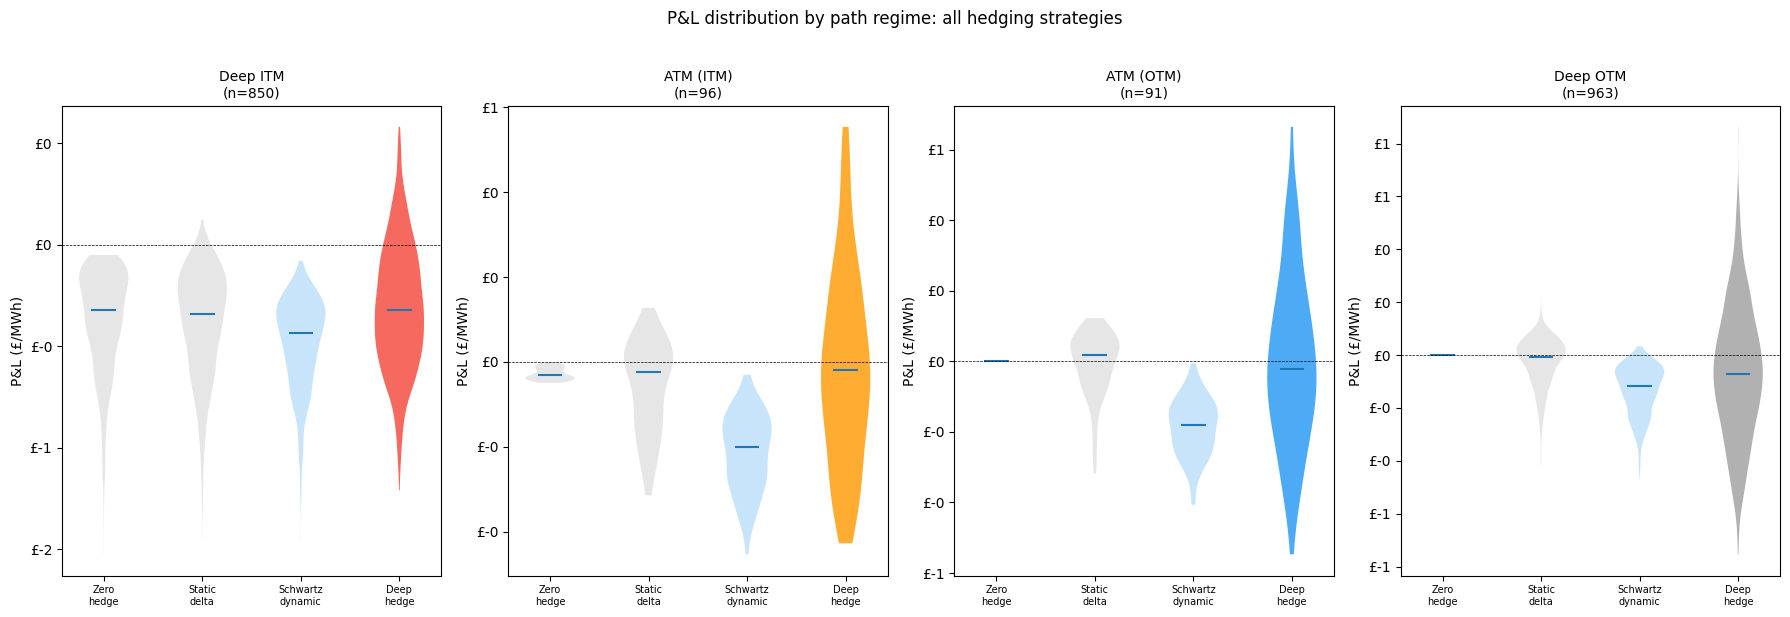

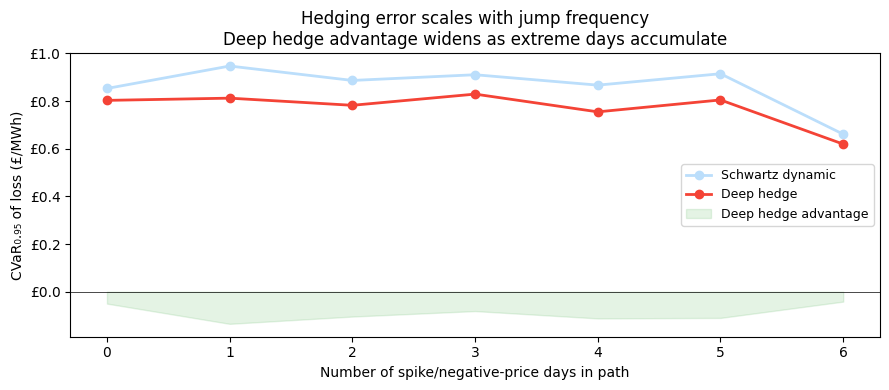

Saved: 07d_pnl_by_regime.png, 07d_cvar_vs_extreme_days.png


In [35]:
# Cell 13 — P&L distribution by regime (violin plot)
#



# Moneyness bucketing — replaces regime labels (OU paths have no regime structure)
avg_prices_test = test_paths.mean(axis=1)
ITM_threshold   = 0.95
OTM_threshold   = 1.05

moneyness = np.where(avg_prices_test < ITM_threshold, "Deep ITM",
            np.where(avg_prices_test < K_NORM,         "ATM (ITM)",
            np.where(avg_prices_test < OTM_threshold,  "ATM (OTM)",
                                                       "Deep OTM")))

COLOURS_M       = {"Deep ITM":  "#F44336", "ATM (ITM)": "#FF9800",
                   "ATM (OTM)": "#2196F3", "Deep OTM":  "#9E9E9E"}
MONEYNESS_ORDER = ["Deep ITM", "ATM (ITM)", "ATM (OTM)", "Deep OTM"]


pnl_dict = {
    "Zero hedge":       pnl_zero,
    "Static delta":     pnl_static,
    "Schwartz dynamic": pnl_schwartz,
    "Deep hedge":       pnl_deep,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)
for ax, regime in zip(axes, MONEYNESS_ORDER):
    mask   = moneyness == regime
    n_mask = mask.sum()
    data   = [pnl[mask] for pnl in pnl_dict.values()]
    labels = list(pnl_dict.keys())

    parts = ax.violinplot(data, positions=range(len(labels)),
                          showmedians=True, showextrema=False)
    for pc, lbl in zip(parts["bodies"], labels):
        c = (COLOURS_M[regime] if lbl == "Deep hedge"
             else "#BBDEFB" if lbl == "Schwartz dynamic"
             else "#E0E0E0")
        pc.set_facecolor(c)
        pc.set_alpha(0.8)

    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_title(f"{regime}\n(n={n_mask})", fontsize=10)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([l.replace(" ", "\n") for l in labels], fontsize=7)
    ax.set_ylabel("P&L (£/MWh)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("£%.0f"))

plt.suptitle("P&L distribution by path regime: all hedging strategies",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "07d_pnl_by_moneyness.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Additional: CVaR vs number of spike+negative days ---
# Count extreme days per test path
extreme_days = ((regimes_test == 2) | (regimes_test == 3)).sum(axis=1)  # (N_test,)
max_extreme  = int(extreme_days.max())

bins     = np.arange(0, min(max_extreme + 2, 12))
cvar_sw  = []
cvar_dh  = []
bin_ns   = []

for b in bins:
    mask = extreme_days == b
    if mask.sum() < 10:
        continue
    _, c_sw = empirical_cvar(pnl_schwartz[mask])
    _, c_dh = empirical_cvar(pnl_deep[mask])
    cvar_sw.append(c_sw)
    cvar_dh.append(c_dh)
    bin_ns.append(b)

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(bin_ns, cvar_sw, "o-", color="#BBDEFB", lw=2, label="Schwartz dynamic")
ax2.plot(bin_ns, cvar_dh, "o-", color="#F44336", lw=2, label="Deep hedge")
ax2.fill_between(bin_ns,
    [c_dh - c_sw for c_dh, c_sw in zip(cvar_dh, cvar_sw)],
    0, alpha=0.15, color="#4CAF50", label="Deep hedge advantage")
ax2.axhline(0, color="black", lw=0.5)
ax2.set_xlabel("Number of spike/negative-price days in path")
ax2.set_ylabel("CVaR₀.₉₅ of loss (£/MWh)")
ax2.set_title("Hedging error scales with jump frequency\n"
              "Deep hedge advantage widens as extreme days accumulate")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("£%.1f"))
plt.tight_layout()
plt.savefig(DATA_DIR / "07d_cvar_vs_extreme_days.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07d_pnl_by_regime.png, 07d_cvar_vs_extreme_days.png")

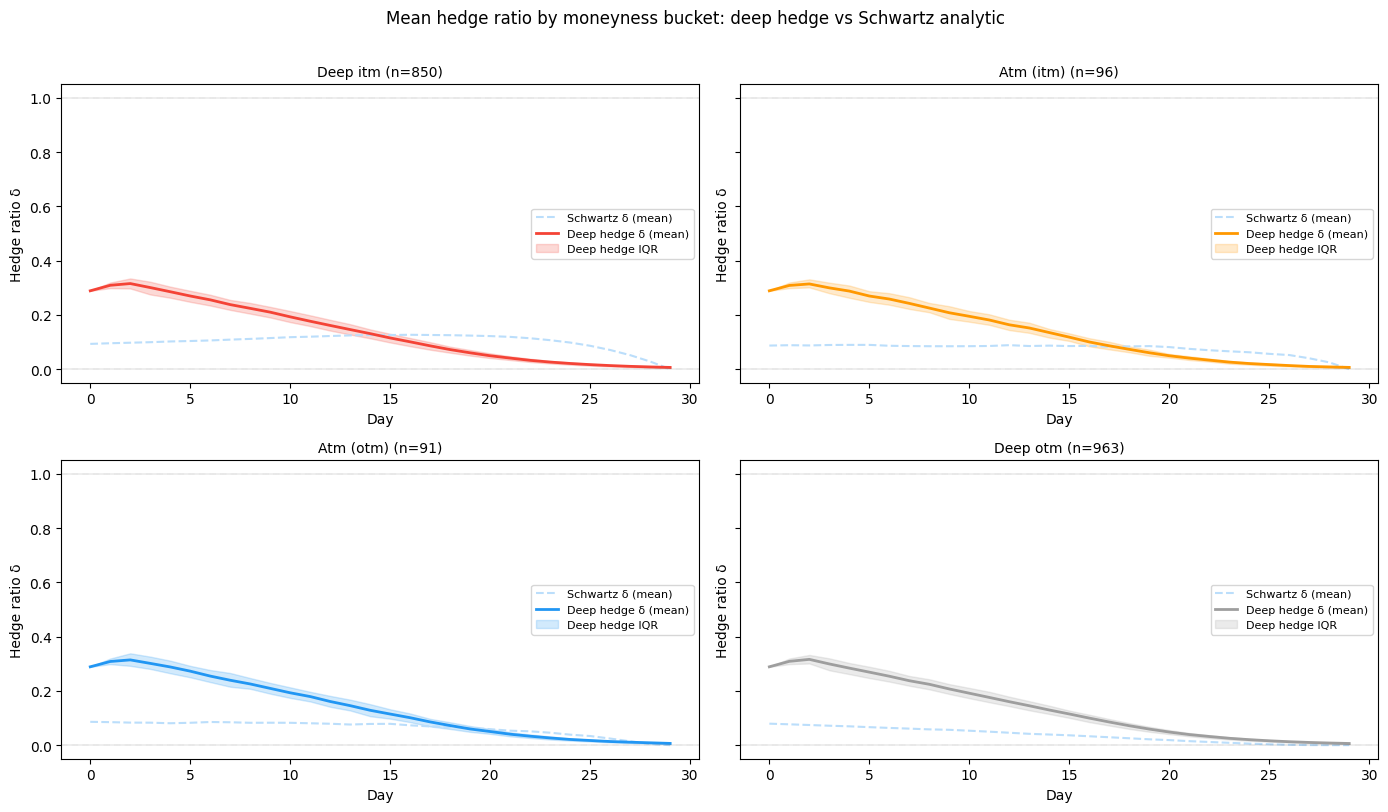

Saved: 07d_hedge_ratio_by_regime.png


In [33]:
# Cell 14 — Hedge ratio over time
#
# Mean δ_t by regime: deep hedge vs Schwartz dynamic.
# Shows how the deep hedger's behaviour diverges from the parametric delta
# in spike and negative regimes — the key qualitative result.

delta_deep_np = deltas_deep_test.cpu().numpy()   # (2000, 30)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.ravel()
t_axis = np.arange(T_DAYS)

for ax, regime in zip(axes, MONEYNESS_ORDER):
    mask = moneyness == regime
    if mask.sum() < 5:
        ax.set_title(f"{regime} (insufficient paths)")
        continue

    dh_mean = delta_deep_np[mask].mean(axis=0)       # (T,)
    sw_mean = delta_sw_te[mask].mean(axis=0)         # (T,)
    dh_p25  = np.percentile(delta_deep_np[mask], 25, axis=0)
    dh_p75  = np.percentile(delta_deep_np[mask], 75, axis=0)

    ax.plot(t_axis, sw_mean, ls="--", lw=1.5, color="#BBDEFB",
            label="Schwartz δ (mean)")
    ax.plot(t_axis, dh_mean, lw=2, color=COLOURS_M[regime],
            label="Deep hedge δ (mean)")
    ax.fill_between(t_axis, dh_p25, dh_p75,
                    alpha=0.2, color=COLOURS_M[regime], label="Deep hedge IQR")

    ax.set_title(f"{regime.capitalize()} (n={mask.sum()})", fontsize=10)
    ax.set_xlabel("Day")
    ax.set_ylabel("Hedge ratio δ")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.axhline(0, color="black", lw=0.3, ls=":")
    ax.axhline(1, color="black", lw=0.3, ls=":")

plt.suptitle("Mean hedge ratio by moneyness bucket: deep hedge vs Schwartz analytic",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "07d_hedge_ratio_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07d_hedge_ratio_by_regime.png")

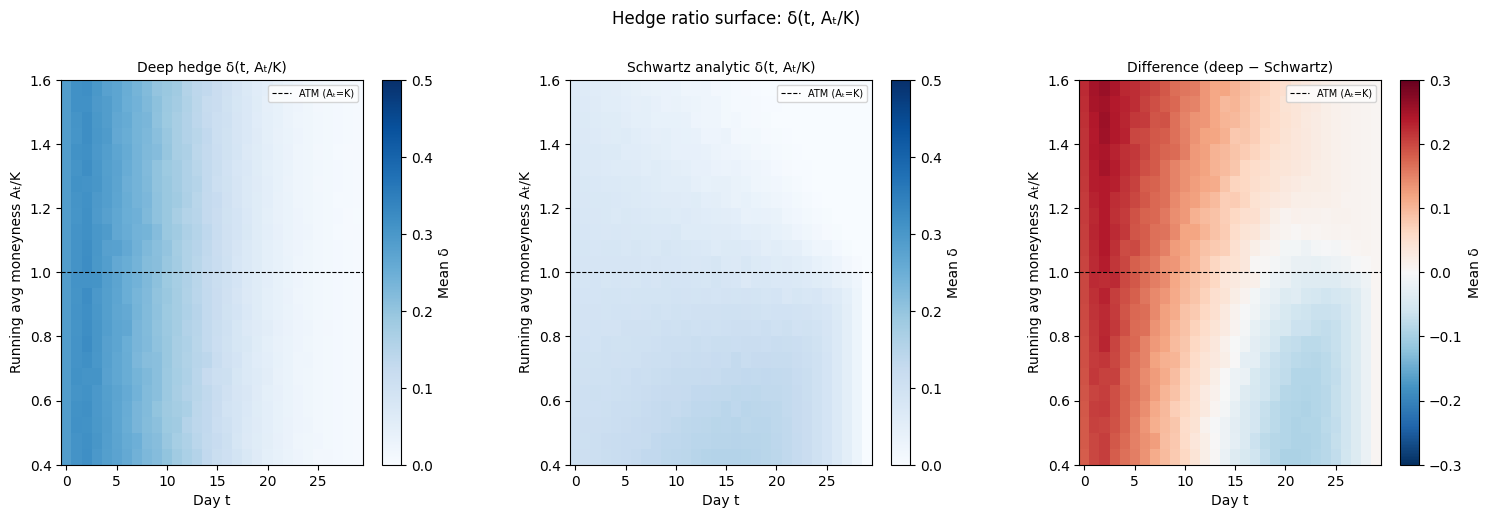

Saved: 07d_hedge_ratio_surface.png


In [34]:
# Cell 15 — Hedge ratio surface: deep hedge vs Schwartz analytic
#
# For each path at each step t, compute the running average price A_t.
# Bin paths by (t, A_t/K_NORM) and plot mean delta as a heatmap surface.
# Shows the full learned policy δ(t, moneyness) vs the analytic Schwartz delta.

from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec

# Running average at each step
running_avg_te = (np.cumsum(test_paths, axis=1) /
                  np.arange(1, T_DAYS + 1))          # (N_te, T)

# Moneyness bins: A_t / K_NORM
MONO_BINS    = np.linspace(0.4, 1.6, 25)             # 24 bins
mono_centres = 0.5 * (MONO_BINS[:-1] + MONO_BINS[1:])
t_axis       = np.arange(T_DAYS)
MIN_COUNT    = 5                                      # skip sparse bins

surf_deep = np.full((len(mono_centres), T_DAYS), np.nan)
surf_sw   = np.full((len(mono_centres), T_DAYS), np.nan)

for ti in range(T_DAYS):
    mono_t = running_avg_te[:, ti] / K_NORM
    for mi, (lo, hi) in enumerate(zip(MONO_BINS[:-1], MONO_BINS[1:])):
        mask = (mono_t >= lo) & (mono_t < hi)
        if mask.sum() >= MIN_COUNT:
            surf_deep[mi, ti] = delta_deep_np[mask, ti].mean()
            surf_sw[mi, ti]   = delta_sw_te[mask, ti].mean()

surf_diff = surf_deep - surf_sw

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

panels = [
    (surf_deep, "Deep hedge δ(t, Aₜ/K)",       "Blues",   0.0,  0.5),
    (surf_sw,   "Schwartz analytic δ(t, Aₜ/K)", "Blues",   0.0,  0.5),
    (surf_diff, "Difference (deep − Schwartz)",  "RdBu_r", -0.3, 0.3),
]

for i, (data, title, cmap, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(gs[i])
    im = ax.pcolormesh(t_axis, mono_centres, data,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       shading="auto")
    ax.axhline(1.0, color="black", lw=0.8, ls="--", label="ATM (Aₜ=K)")
    ax.set_xlabel("Day t")
    ax.set_ylabel("Running avg moneyness Aₜ/K")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, label="Mean δ")
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Hedge ratio surface: δ(t, Aₜ/K)", fontsize=12, y=1.02)
plt.savefig(DATA_DIR / "07d_hedge_ratio_surface.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07d_hedge_ratio_surface.png")

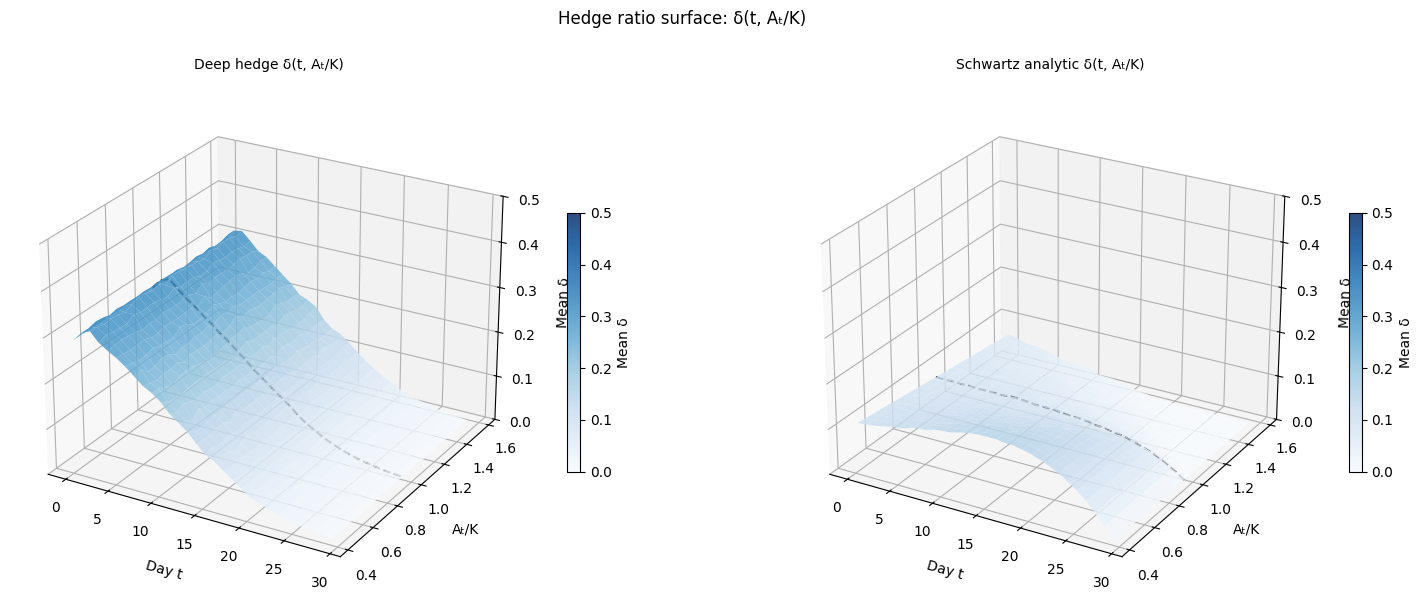

Saved: 07d_hedge_ratio_surface_3d.png


In [36]:
# Cell — 3D hedge ratio surfaces: deep hedge vs Schwartz analytic

from mpl_toolkits.mplot3d import Axes3D

T_grid, M_grid = np.meshgrid(t_axis, mono_centres)

fig = plt.figure(figsize=(16, 6))

for i, (data, title, cmap) in enumerate([
    (surf_deep, "Deep hedge δ(t, Aₜ/K)",        "Blues"),
    (surf_sw,   "Schwartz analytic δ(t, Aₜ/K)", "Blues"),
]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")

    # Mask NaN for surface plot
    Z = np.where(np.isnan(data), 0, data)

    surf = ax.plot_surface(T_grid, M_grid, Z,
                           cmap=cmap, vmin=0, vmax=0.5,
                           alpha=0.85, linewidth=0)

    # ATM line on the surface
    ax.plot(t_axis, np.ones(T_DAYS),
            np.nanmean(data[np.abs(mono_centres - 1.0) < 0.1], axis=0),
            color="black", lw=1.5, ls="--", label="ATM")

    ax.set_xlabel("Day t",         labelpad=8)
    ax.set_ylabel("Aₜ/K",         labelpad=8)
    ax.set_zlabel("Mean δ",        labelpad=8)
    ax.set_zlim(0, 0.5)
    ax.set_title(title, fontsize=10, pad=10)
    ax.view_init(elev=25, azim=-60)
    fig.colorbar(surf, ax=ax, shrink=0.5, label="Mean δ")

plt.suptitle("Hedge ratio surface: δ(t, Aₜ/K)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "07d_hedge_ratio_surface_3d.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07d_hedge_ratio_surface_3d.png")

In [37]:
# Cell 16 — Summary and save results

df_results = pd.DataFrame({
    "path_id":      test_idx,
    "moneyness":    moneyness,
    "avg_price":    test_paths.mean(axis=1),
    "payoff_Z":     Z_test,
    "pnl_zero":     pnl_zero,
    "pnl_static":   pnl_static,
    "pnl_schwartz": pnl_schwartz,
    "pnl_deep":     pnl_deep,
})
df_results.to_parquet(DATA_DIR / "deep_hedge_results.parquet", index=False)
print("Saved: deep_hedge_results.parquet")

summary = {
    "option": {
        "type":     "Asian put",
        "strike":   K_STRIKE,
        "T_days":   T_DAYS,
        "n_paths":  N_PATHS,
        "itm_rate": float((Z_test > 0).mean()),
    },
    "model": {
        "input_dim":        INPUT_DIM,
        "hidden_dim":       HIDDEN_DIM,
        "n_layers":         N_LAYERS,
        "sig_depth":        SIG_DEPTH,
        "logsig_dim":       LOGSIG_DIM,
        "alpha":            ALPHA,
        "cost_bps":         COST_BPS,
        "n_epochs":         N_EPOCHS,
        "final_cvar_loss":  float(cvar_history[-1]),
    },
    "schwartz": {"kappa": KAPPA, "mu": MU, "sigma": SIGMA},
    "test_results": {
        label: {
            "mean_pnl": float(v["mean_pnl"]),
            "std_pnl":  float(v["std_pnl"]),
            "var95":    float(v["var95"]),
            "cvar95":   float(v["cvar95"]),
        } for label, v in results.items()
    },
    "cvar_improvement_vs_schwartz": float(improvement),
}
with open(DATA_DIR / "deep_hedge_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: deep_hedge_summary.json")

print("\n" + "=" * 55)
print("DEEP HEDGING SUMMARY")
print("=" * 55)
print(f"Option:       30-day Asian put, K=£{K_STRIKE}/MWh")
print(f"Paths:        {len(test_idx):,} test paths from Schwartz OU simulation")
print()
for label, v in results.items():
    print(f"{label:20s}  CVaR₀.₉₅ = £{v['cvar95']:7.3f}/MWh")
print()
print(f"CVaR improvement (deep hedge vs Schwartz): £{improvement:.4f}/MWh")
print("=" * 55)
print("Outputs saved to DATA_DIR:")
print("  deep_hedge_results.parquet")
print("  deep_hedge_model.pt")
print("  deep_hedge_summary.json")
print("  07d_training_curve.png")
print("  07d_pnl_by_moneyness.png")
print("  07d_hedge_ratio_surface.png")
print("  07d_hedge_ratio_surface_3d.png")

Saved: deep_hedge_results.parquet
Saved: deep_hedge_summary.json

DEEP HEDGING SUMMARY
Option:       30-day Asian put, K=£80.0/MWh
Paths:        2,000 test paths from Schwartz OU simulation

Zero hedge            CVaR₀.₉₅ = £  0.867/MWh
Static delta          CVaR₀.₉₅ = £  0.882/MWh
Schwartz dynamic      CVaR₀.₉₅ = £  0.907/MWh
Deep hedge            CVaR₀.₉₅ = £  0.804/MWh

CVaR improvement (deep hedge vs Schwartz): £0.1034/MWh
Outputs saved to DATA_DIR:
  deep_hedge_results.parquet
  deep_hedge_model.pt
  deep_hedge_summary.json
  07d_training_curve.png
  07d_pnl_by_moneyness.png
  07d_hedge_ratio_surface.png
  07d_hedge_ratio_surface_3d.png
